## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [2]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [5]:
# TODO: drop the Customer ID column  
df = df.drop(columns='Customer ID')
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [6]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [7]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [8]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [10]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender']=='Male']
female_df = df[df['Gender']=='Female']



## **EDA**

### **Item Purchased**

In [14]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_top = df[df['Gender'] == 'Male']['Item Purchased'].value_counts().reset_index()
female_top = df[df['Gender'] == 'Female']['Item Purchased'].value_counts().reset_index()
all_top = df['Item Purchased'].value_counts().reset_index()
all_top


,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


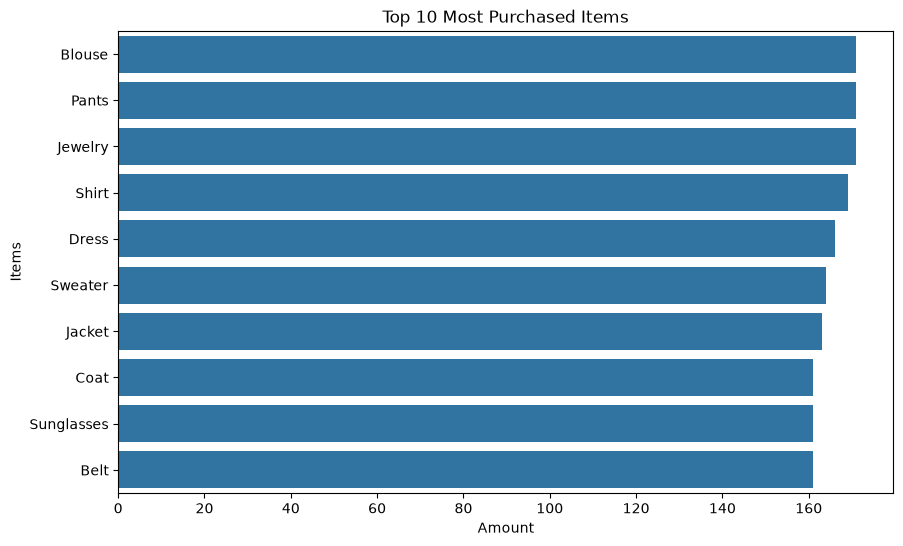

In [ ]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
top_10_items = all_top.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_items,
    y='Item Purchased',
    x='count',
    legend=True
)
plt.title('Top 10 Purchased Items')
plt.xlabel('Amount')
plt.ylabel('Items')
plt.show()

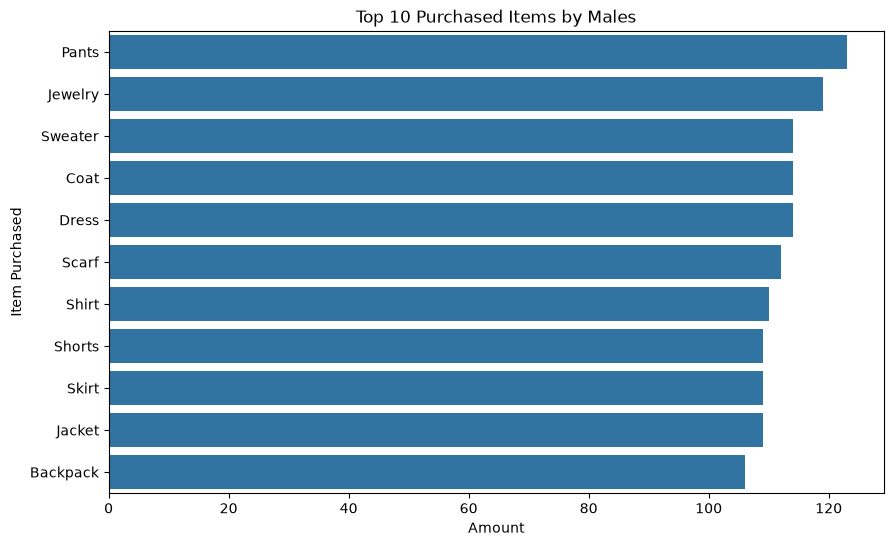

In [97]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
top_10_items_for_male = male_top.head(11)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_items_for_male,
    x='count',
    y='Item Purchased'

)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('Amount')
plt.ylabel('Item Purchased')
plt.show()

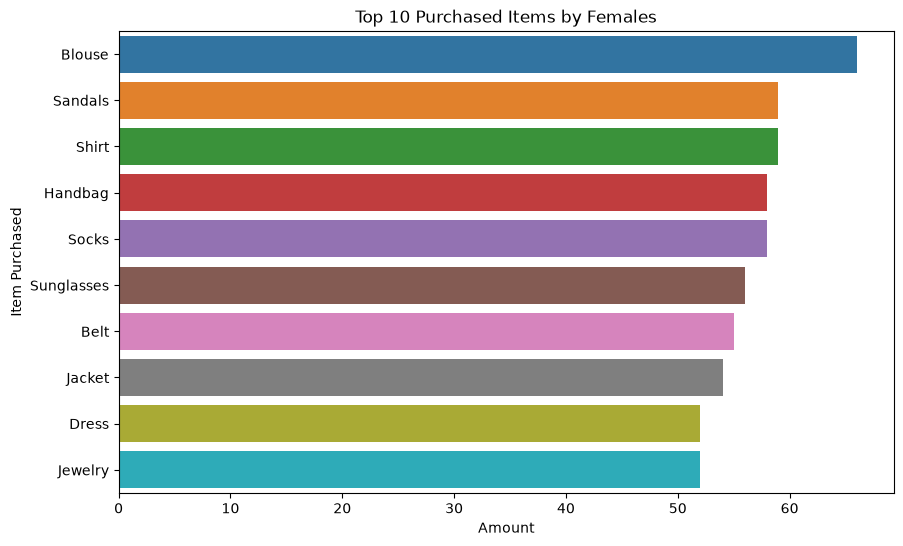

In [17]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
top_10_items_for_female = female_top.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_items_for_female,
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('Amount')
plt.ylabel('Item Purchased')
plt.show()

In [21]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [22]:
# TODO: count Size with value_counts() for male_df and female_df
size_for_male = male_df['Size'].value_counts()
size_for_male

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

In [23]:
size_for_female = female_df['Size'].value_counts()
size_for_female

Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64

### **Category**

In [25]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg


,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [26]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_for_male = male_df['Category'].value_counts().reset_index()
ctg_for_male

,Category,count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


In [27]:
ctg_for_female = female_df['Category'].value_counts().reset_index()
ctg_for_female

,Category,count
0,Clothing,556
1,Accessories,392
2,Footwear,199
3,Outerwear,101


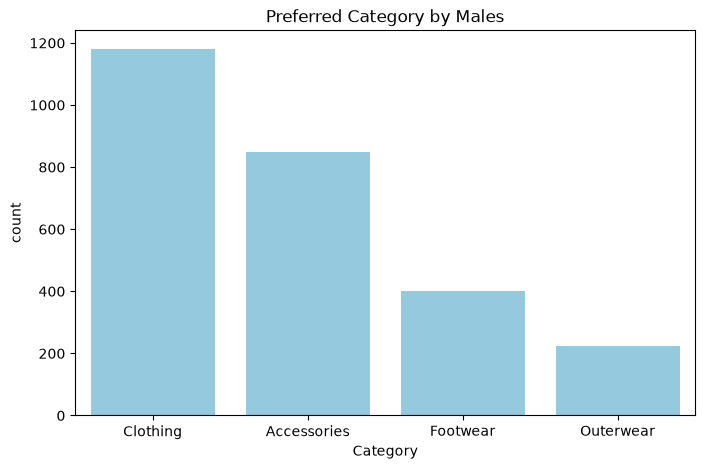

In [29]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_for_male,
    x='Category',
    y='count',
    color='skyblue'
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

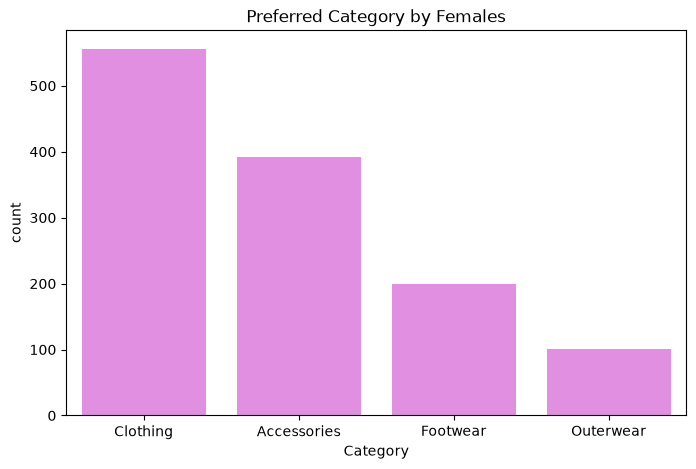

In [30]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data= ctg_for_female,
   x='Category',
   y='count',
   color='violet'
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

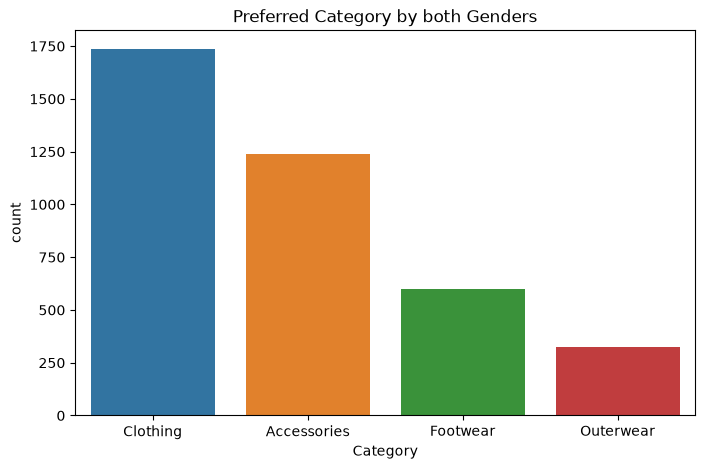

In [31]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [ ]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())
waffle_data_m

# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())

{'Clothing': np.int64(1181), 'Accessories': np.int64(848), 'Footwear': np.int64(400), 'Outerwear': np.int64(223)}


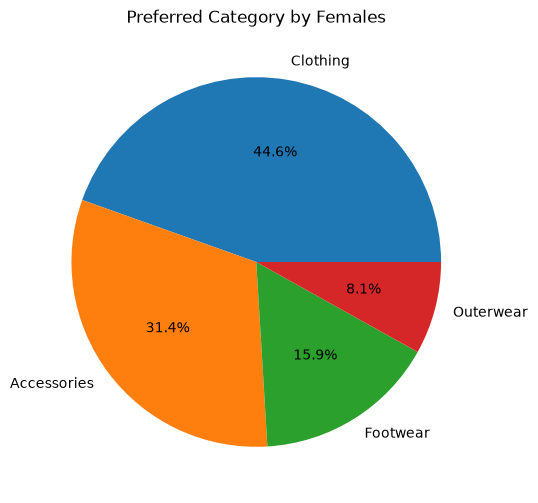

In [38]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
labels = ctg_for_female['Category']
plt.figure(figsize=(6, 6))
plt.pie(
    ctg_for_female['count'],
    labels=labels,
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

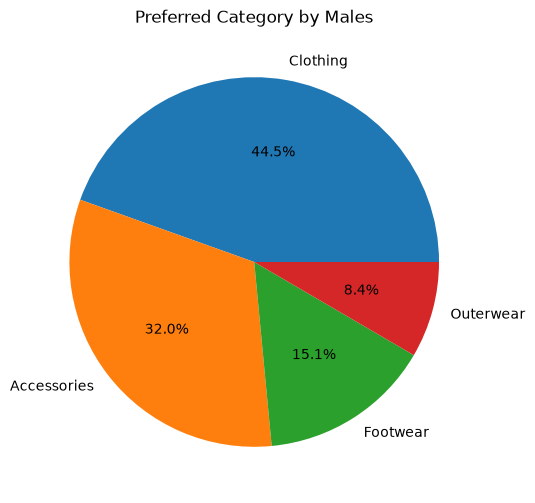

In [39]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [ ]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category']=='Clothing']
avg_cr_f = cr_f['Review Rating'].mean()


3.704


In [ ]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category']=='Clothing']
avg_cr_m = cr_m['Review Rating'].mean()


3.732


In [56]:
# avg_cr_m,avg_cr_f
print('Mean of Review Rating Clothing of Male: ',avg_cr_f.round(3))
print('Mean of Review Rating Clothing of Female: ',avg_cr_m.round(3))

Mean of Review Rating Clothing of Male:  3.704
Mean of Review Rating Clothing of Female:  3.732


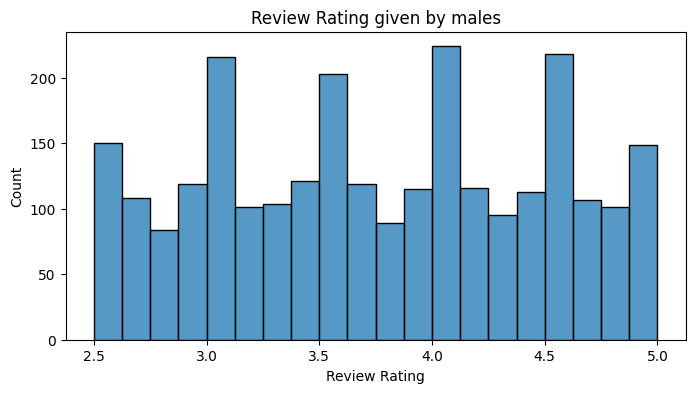

In [ ]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.xlabel('Review Rating')
plt.ylabel('Count')
plt.show()



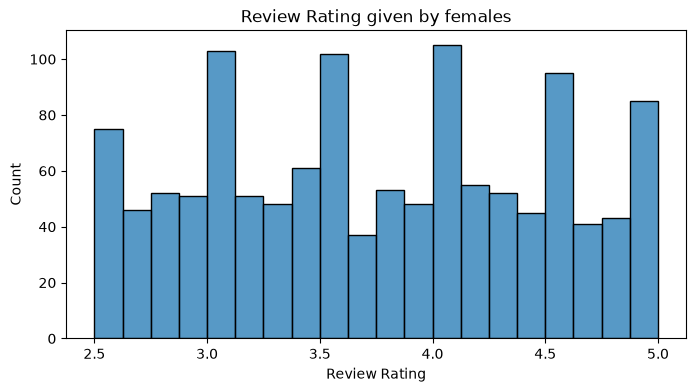

In [57]:
# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.xlabel('Review Rating')
plt.ylabel('Count')
plt.show()

In [61]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
count_RR = cr_m['Review Rating'].value_counts().reset_index().sort_values('Review Rating')
count_RR

,Review Rating,count
24,2.5,17
17,2.6,45
2,2.7,55
21,2.8,41
3,2.9,55
8,3.0,49
12,3.1,46
20,3.2,41
7,3.3,49
1,3.4,59


### **Purchase Amount (USD)**

In [65]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

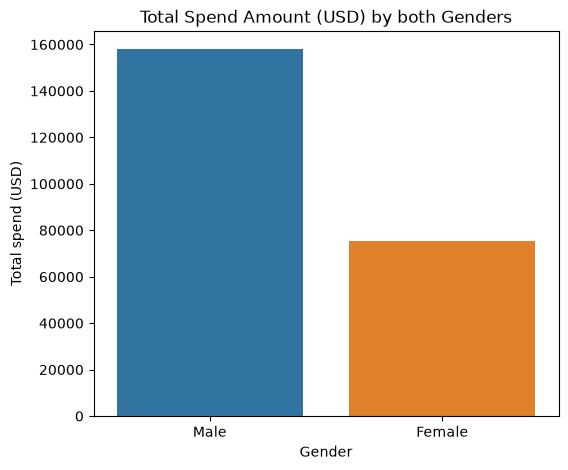

In [67]:
# TODO: plot total spend by gender with sns.barplot()
total_spend = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total_Spend': [m_tpa, f_tpa]
})
plt.figure(figsize=(6, 5))
sns.barplot(
    data=total_spend,
    y='Total_Spend',
    x='Gender',
    hue='Gender'
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [68]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category']=='Footwear']
co_f = female_df[female_df['Category']=='Outerwear']

In [69]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category']=='Footwear']
co_m = male_df[male_df['Category']=='Outerwear']

In [ ]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu_dict = dict(df['Promo Code Used'].value_counts())


{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

<Axes: >

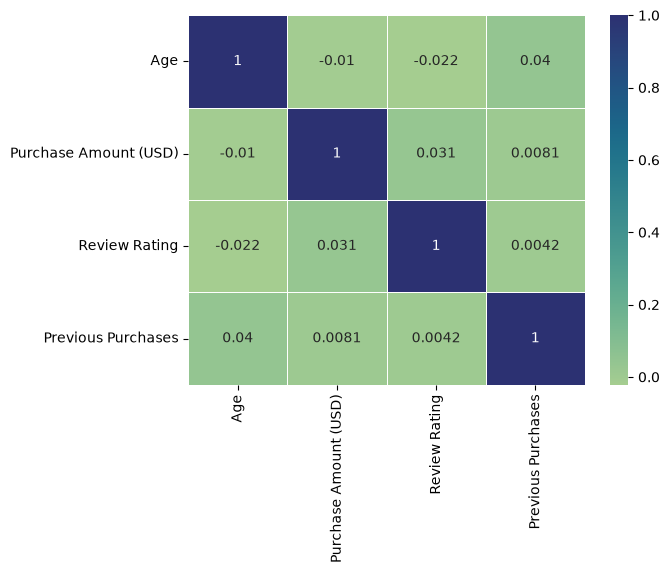

In [75]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    linewidths=.5,
    cmap='crest'
)

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [81]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender','Size','Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [83]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
minmax = MinMaxScaler()
std = StandardScaler()
df['Amount_minmax'] = minmax.fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = std.fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [90]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
labels = ['Low','Medium','High']
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'],labels=labels,bins=range(0,100,25))
df['Amount_bin'].value_counts()


Amount_bin
Medium    1209
High      1172
Low        305
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Items are the most common for males: Pants, Jewelry, Sweater, Coat, Dress, Scarf, Shirt,
Shorts, Jacket, Backpack.
- Items are the most common for females: Blouse, Sandals, Shirt, Handbag, Socks, Sunglasses,
Belt, Jacket, Dress, Jewelry
- Category is the most common for both Gender: Clothing
- No, males spend more in total amount than females.
- Yes, the Review Ratings are similar between males and females. Review Rating of Males is 3,73 and Females is 3,70 
- Promo codes are not used very frequently. Most customers do not use promo codes (2,223 customers), while 1,677 customers use them.

Caveat: correlation is not causation.